In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_jobs_with_skills.csv")
print("dataset shape :", df.shape)
print(df.columns.tolist())

dataset shape : (7996, 19)
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills', 'regex_Phrase_skills']


In [3]:
print(df["clean_description"].isnull().sum())

0


In [4]:
print(df["clean_description"].head())

0    job description send me jobs like this qualifi...
1    job description send me jobs like this qualifi...
2    job description send me jobs like this as a de...
3    job description send me jobs like this involve...
4    job description send me jobs like this please ...
Name: clean_description, dtype: str


# Create TF IDF Vectorizer

In [5]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

# Create matrix

In [6]:
X = vectorizer.fit_transform(
    df["clean_description"]
)

In [7]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (7996, 1000)


# Get feature names

In [8]:
terms = vectorizer.get_feature_names_out()

print("Number of terms:", len(terms))
print(terms[:20])

Number of terms: 1000
['ability' 'able' 'access' 'according' 'account' 'accountant' 'accounting'
 'accounts' 'achieve' 'achieving' 'acquisition' 'act' 'action' 'active'
 'activities' 'ad' 'added' 'additional' 'address' 'admin']


# calculate score

In [9]:
tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
tfidf_df = pd.DataFrame({
    "term": terms,
    "tfidf_score": tfidf_scores
})

In [10]:
tfidf_df = tfidf_df.sort_values(
    by="tfidf_score",
    ascending=False
)
print(tfidf_df.head(20))

               term  tfidf_score
862        software   642.456973
270       doctorate   555.560747
486             job   455.765699
333      experience   435.644152
816           sales   429.590182
810            role   425.797110
737         profile   423.782915
240     description   405.137548
873  specialization   393.150903
789        required   358.041946
241          design   342.322632
843        services   323.263024
160         company   318.022046
256     development   317.074276
108        business   315.549012
739     programming   301.947793
539      management   290.908413
856          skills   283.091258
449        industry   259.976430
114       candidate   246.495586


# Calculate mean

In [11]:
mean_scores = np.asarray(
    X.mean(axis=0)
).flatten()

tfidf_mean_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
})

In [12]:
tfidf_mean_df = tfidf_mean_df.sort_values(
    by="mean_tfidf",
    ascending=False
)
print(tfidf_mean_df.head(20))

               term  mean_tfidf
862        software    0.080347
270       doctorate    0.069480
486             job    0.056999
333      experience    0.054483
816           sales    0.053726
810            role    0.053251
737         profile    0.052999
240     description    0.050668
873  specialization    0.049168
789        required    0.044778
241          design    0.042812
843        services    0.040428
160         company    0.039773
256     development    0.039654
108        business    0.039463
739     programming    0.037762
539      management    0.036382
856          skills    0.035404
449        industry    0.032513
114       candidate    0.030827


In [13]:
# Get top TF-IDF keywords for each job

feature_names = vectorizer.get_feature_names_out()

def get_top_tfidf_keywords(row, top_n=10):
    scores = row.toarray().flatten()

    top_indices = scores.argsort()[-top_n:][::-1]

    keywords = [
        feature_names[i]
        for i in top_indices
        if scores[i] > 0
    ]

    return keywords

In [14]:
df["tfidf_keywords"] = [
    get_top_tfidf_keywords(X[i], top_n=10)
    for i in range(X.shape[0])
]
df[
    ["clean_description", "tfidf_keywords"]
].head()

,clean_description,tfidf_keywords
0,job description send me jobs like this qualifi...,"[info, selection, media, day, time, data, proc..."
1,job description send me jobs like this qualifi...,"[infotech, day, selection, marketing, pr, mr, ..."
2,job description send me jobs like this as a de...,"[sql, complex, application, pl, testing, desig..."
3,job description send me jobs like this involve...,"[tax, day, various, service, planning, complia..."
4,job description send me jobs like this please ...,"[js, open, tech, technologies, software, passi..."


In [15]:
df.to_csv("clean_jobs_with_skills.csv", index=False)

In [16]:
print(df.columns.tolist())

['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length', 'dictionary_skills', 'regex_Phrase_skills', 'tfidf_keywords']


# Top 20 keywords

In [17]:
top_20 = tfidf_mean_df.head(20)

display(top_20)

,term,mean_tfidf
862,software,0.080347
270,doctorate,0.069480
486,job,0.056999
333,experience,0.054483
816,sales,0.053726
810,role,0.053251
737,profile,0.052999
240,description,0.050668
873,specialization,0.049168
789,required,0.044778


# Create Visualization

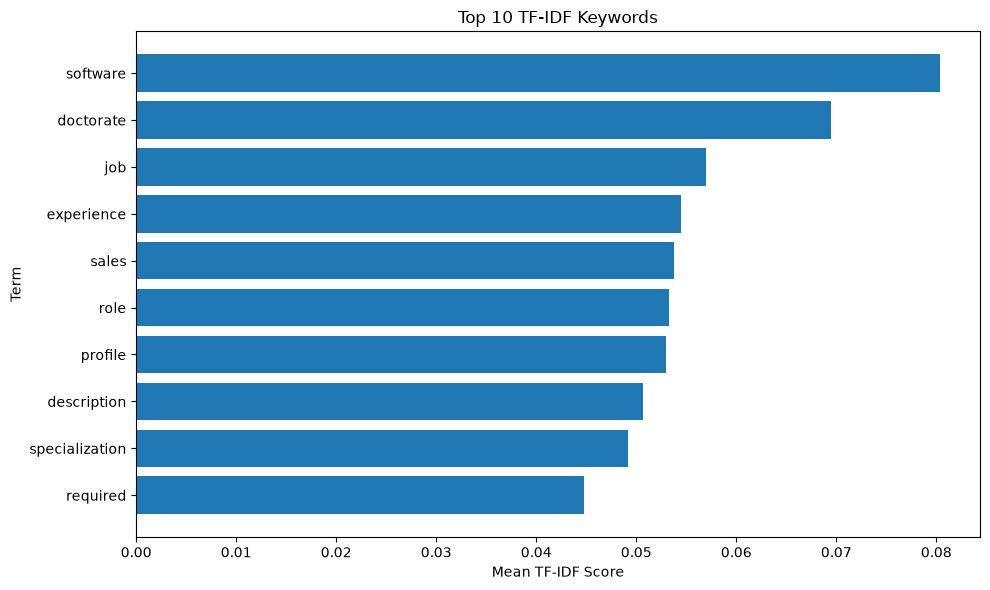

In [19]:
top_10 = tfidf_mean_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["term"][::-1],
    top_10["mean_tfidf"][::-1]
)

plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.title("Top 10 TF-IDF Keywords")

plt.tight_layout()

# plt.savefig(
#     "top_10_tfidf_keywords.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# Compare  with my taxonomy

In [20]:
taxonomy = pd.read_csv("skill_taxonomy.csv")

In [21]:
taxonomy_skills = set(
    taxonomy["skill"].dropna().str.lower().str.strip()
)

In [22]:
tfidf_df["is_skill"] = (
    tfidf_df["term"].str.lower()
    .isin(taxonomy_skills)
)

In [23]:
print(
    tfidf_df[
        tfidf_df["is_skill"] == True
    ].head(20)
)

              term  tfidf_score  is_skill
157  communication   172.860503      True
99             bpo   160.641669      True
483           java   146.558752      True
632     operations   136.509634      True
877            sql   113.275659      True
636         oracle   112.648083      True
484     javascript    77.131690      True
304        english    69.537334      True
499            kpo    61.455795      True
471       internet    61.014960      True
423           html    58.124588      True
677            php    50.561433      True
203            css    45.900401      True
323          excel    39.922112      True
755         python    35.910086      True
595          mysql    34.853984      True


# Top skills

In [24]:
tfidf_skills = tfidf_df[
    tfidf_df["is_skill"] == True
].copy()

In [25]:
tfidf_skills = tfidf_skills.sort_values(
    by="tfidf_score",
    ascending=False
)
display(
    tfidf_skills.head(20)
)

,term,tfidf_score,is_skill
157,communication,172.860503,True
99,bpo,160.641669,True
483,java,146.558752,True
632,operations,136.509634,True
877,sql,113.275659,True
636,oracle,112.648083,True
484,javascript,77.131690,True
304,english,69.537334,True
499,kpo,61.455795,True
471,internet,61.014960,True


# Find new candidate terms

In [26]:
new_candidate_terms = tfidf_df[
    tfidf_df["is_skill"] == False
]
display(new_candidate_terms.head(10))

,term,tfidf_score,is_skill
862,software,642.456973,False
270,doctorate,555.560747,False
486,job,455.765699,False
333,experience,435.644152,False
816,sales,429.590182,False
810,role,425.797110,False
737,profile,423.782915,False
240,description,405.137548,False
873,specialization,393.150903,False
789,required,358.041946,False


In [27]:
print(taxonomy_skills)

{'java', 'php', 'tailwind css', 'ansible', 'kafka', 'data processing', 'natural language processing', 'node.js', 'scipy', 'oracle', 'hive', 'azure data factory', 'sql', 'spacy', 'powerpoint', 'hugging face', 'data science', 'communication', 'english typing', 'hindi', 'amazon ec2', 'kpo', 'tamil', 'c++', 'customer service', 'postgresql', 'machine learning', 'c', 'express.js', 'tensorflow', 'docker', 'terraform', 'cybersecurity', 'github', 'operations', 'penetration testing', 'keras', 'amazon s3', 'transformers', 'angular', 'nlp', 'xgboost', 'vue.js', 'redis', 'computer fundamentals', 'computer vision', 'jenkins', 'next.js', 'pytorch', 'ms office', 'mongodb', 'looker', 'matplotlib', 'seaborn', 'deep learning', 'nltk', 'call center', 'data analysis', 'gcp', 'excel', 'tableau', 'customer support', 'mysql', 'ms word', 'network security', 'internet', 'artificial intelligence', 'typing', 'gitlab', 'email handling', 'css', 'typescript', 'ethical hacking', 'html', 'bpo', 'aws glue', 'c#', 'pand

In [28]:
print(tfidf_df["term"].head(10))

862          software
270         doctorate
486               job
333        experience
816             sales
810              role
737           profile
240       description
873    specialization
789          required
Name: term, dtype: str
